In [2]:
from luminis_mc import ResultsLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
def gaussian_2d_func(coords, amplitude, xo, yo, sigma, offset):
    x, y = coords
    g = offset + amplitude * np.exp( -((x-xo)**2 + (y-yo)**2) / (2*sigma**2) )
    return g.ravel()

def plot_figure_5_corrected(I_inst, I_avg_raw, NN, HW):
    # Crear grid espacial
    x = np.linspace(-HW, HW, NN)
    y = np.linspace(-HW, HW, NN)
    X, Y = np.meshgrid(x, y)

    # ... (El bloque de ajuste Gaussiano se queda igual) ...
    # Copia el bloque "try/except" y cálculo de "eta" de tu código anterior aquí
    # o usa el script completo de abajo.

    # --- REPETIMOS EL AJUSTE PARA QUE EL CÓDIGO ESTÉ COMPLETO ---
    x_flat = X.ravel()
    y_flat = Y.ravel()
    z_flat = I_avg_raw.ravel()
    initial_guess = [np.max(I_avg_raw), 0, 0, 10, 0]

    try:
        popt, pcov = curve_fit(gaussian_2d_func, (x_flat, y_flat), z_flat, p0=initial_guess)
        I_avg_smooth = gaussian_2d_func((X, Y), *popt).reshape(NN, NN)
    except:
        I_avg_smooth = I_avg_raw

    mask = I_avg_smooth > (np.max(I_avg_smooth) * 0.01)
    eta = I_inst[mask] / I_avg_smooth[mask]
    # -----------------------------------------------------------

    # --- GRAFICACIÓN ---
    fig = plt.figure(figsize=(16, 10))

    # (a) Instantaneous Ix
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.imshow(I_inst, extent=[-HW, HW, -HW, HW], cmap='gray', origin='lower')
    # CORRECCIÓN 1: Añadir r antes de las comillas si hay LaTeX (opcional aquí, pero buena práctica)
    ax1.set_title(r"(a) Instantaneous Intensity $I_x$")
    ax1.set_xlabel(r"x ($l_s$)")

    # (b) Average Ix
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.imshow(I_avg_raw, extent=[-HW, HW, -HW, HW], cmap='gray', origin='lower')
    ax2.set_title(r"(b) Average Intensity $\langle I_x \rangle$ (Raw)")
    ax2.set_xlabel(r"x ($l_s$)")

    # (c) Probability Density
    ax3 = fig.add_subplot(2, 3, 3)
    hist, bins = np.histogram(eta, bins=60, density=True)
    centers = (bins[:-1] + bins[1:]) / 2

    ax3.semilogy(centers, hist, 'mo', mfc='none', label='Simulación')

    x_theory = np.linspace(0, 10, 100)
    # CORRECCIÓN 2: Añadir r'' aquí por el \eta
    ax3.semilogy(x_theory, np.exp(-x_theory), 'k-', linewidth=2, label=r'Teoría $e^{-\eta}$')

    ax3.set_title("(c) Probability Density")
    # CORRECCIÓN 3: Añadir r'' aquí (ESTA ES LA QUE CAUSABA EL CRASH PRINCIPAL)
    ax3.set_xlabel(r"$\eta = I_x / \langle I_x \rangle$")

    ax3.set_ylim(1e-4, 1)
    ax3.set_xlim(0, 10)
    ax3.legend()
    ax3.grid(True, which="both", ls="--", alpha=0.2)

    # (d) 3D Surface
    ax4 = fig.add_subplot(2, 3, 4, projection='3d')
    surf = ax4.plot_surface(X, Y, I_avg_smooth, cmap='jet', linewidth=0, antialiased=False)
    ax4.set_title("(d) Avg Intensity (Fitted Profile)")

    # (e) Cross Section X
    ax5 = fig.add_subplot(2, 3, 5)
    mid_idx = NN // 2
    ax5.plot(x, I_avg_raw[mid_idx, :], 'm-', alpha=0.4, label='Data (Raw)')
    ax5.plot(x, I_avg_smooth[mid_idx, :], 'k-', linewidth=2, label='Fit')
    ax5.set_title("(e) Cross Section X")
    ax5.legend()

    # (f) Cross Section Y
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.plot(y, I_avg_raw[:, mid_idx], 'm-', alpha=0.4, label='Data (Raw)')
    ax6.plot(y, I_avg_smooth[:, mid_idx], 'k-', linewidth=2, label='Fit')
    ax6.set_title("(f) Cross Section Y")

    plt.tight_layout()
    # plt.savefig("replicate_fig5_corrected.png", dpi=150)
    plt.show()


In [4]:
# base_dir = "/Users/niaggar/Documents/Thesis/Progress/23Feb26/2026-02-22_09-34-11_speckel/runs/"
base_dir = "/Users/niaggar/Documents/Thesis/Progress/02Mar26/"
dir_name = "2026-02-23_12-51-02_speckel"
data = ResultsLoader(base_dir + dir_name)

meta_sensor_fluence = data.sensor_meta("planarfluence")
meta_sensor_electric = data.sensor_meta("planarfield")
print(meta_sensor_fluence)
print(meta_sensor_electric)

{'N_t': np.int64(1), 'N_x': np.int64(400), 'N_y': np.int64(400), 'absorb_photons': np.True_, 'backward_normal': array([-0., -0., -1.]), 'dt': np.float64(0.0), 'dx': np.float64(0.1), 'dy': np.float64(0.1), 'estimator_enabled': np.False_, 'filter_phi_enabled': np.False_, 'filter_phi_max': np.float64(0.0), 'filter_phi_min': np.float64(0.0), 'filter_position_enabled': np.True_, 'filter_theta_enabled': np.False_, 'filter_theta_max': np.float64(0.0), 'filter_theta_min': np.float64(0.0), 'filter_x_max': np.float64(20.0), 'filter_x_min': np.float64(-20.0), 'filter_y_max': np.float64(20.0), 'filter_y_min': np.float64(-20.0), 'hits': np.int64(3097872), 'id': '1', 'len_t': np.float64(0.0), 'len_x': np.float64(40.0), 'len_y': np.float64(40.0), 'm_polarization': array([1., 0., 0.]), 'n_polarization': array([0., 1., 0.]), 'normal': array([0., 0., 1.]), 'origin': array([0., 0., 0.]), 'type': 'PlanarFluenceSensor'}
{'N_x': np.int64(400), 'N_y': np.int64(400), 'absorb_photons': np.True_, 'backward_norm

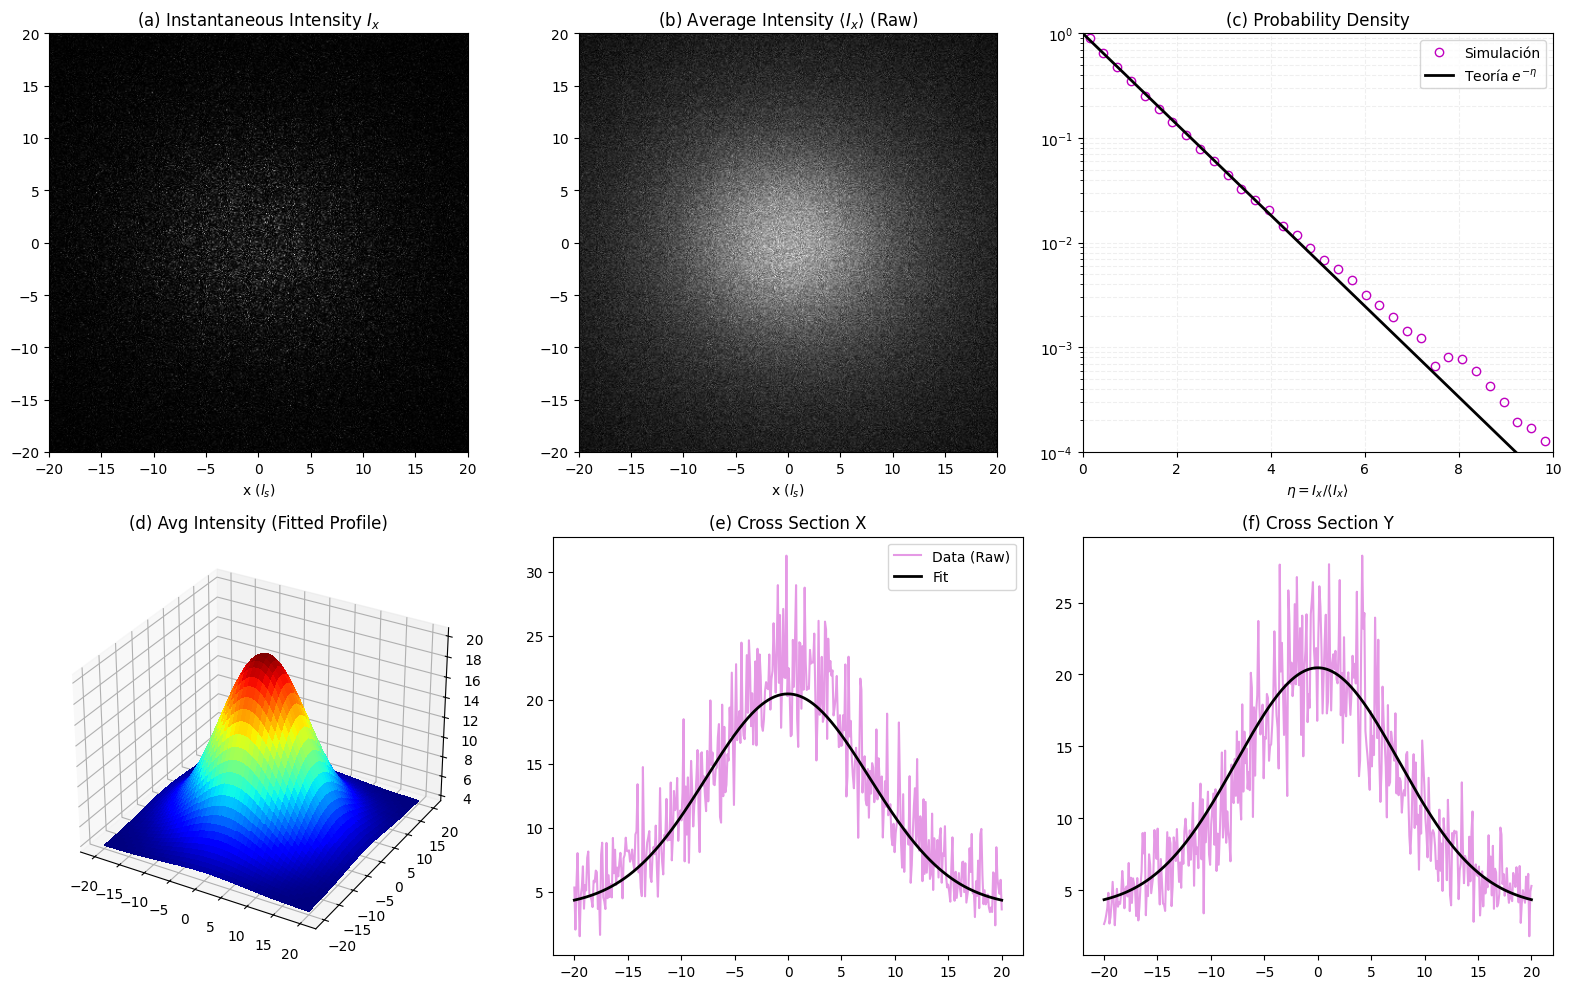

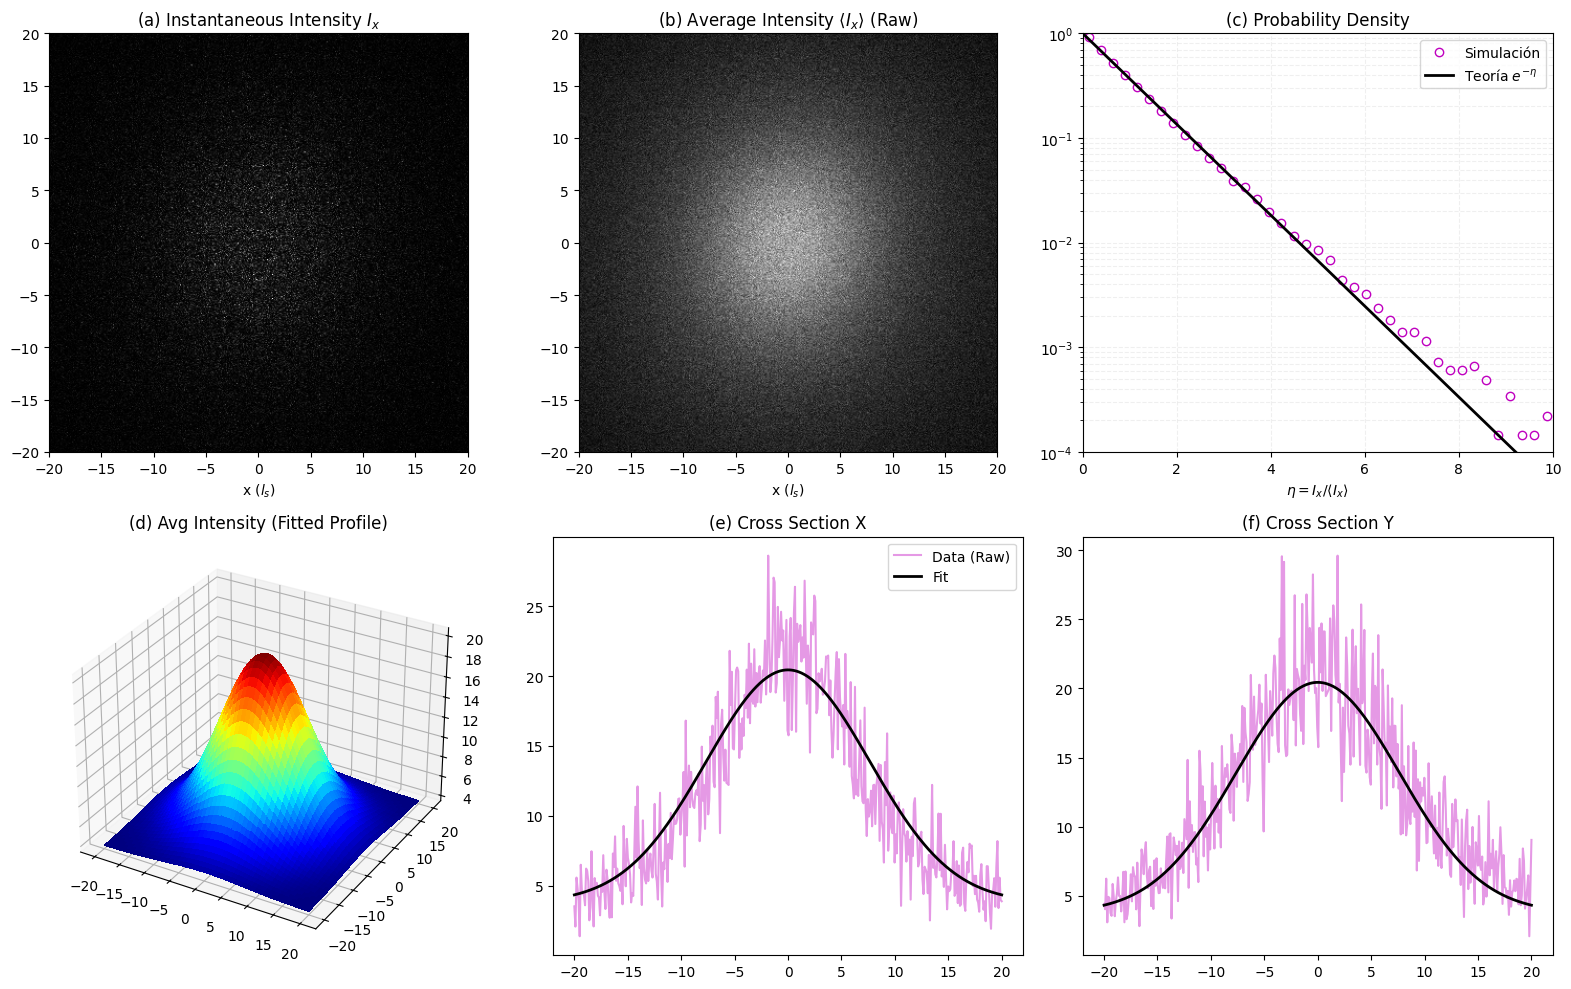

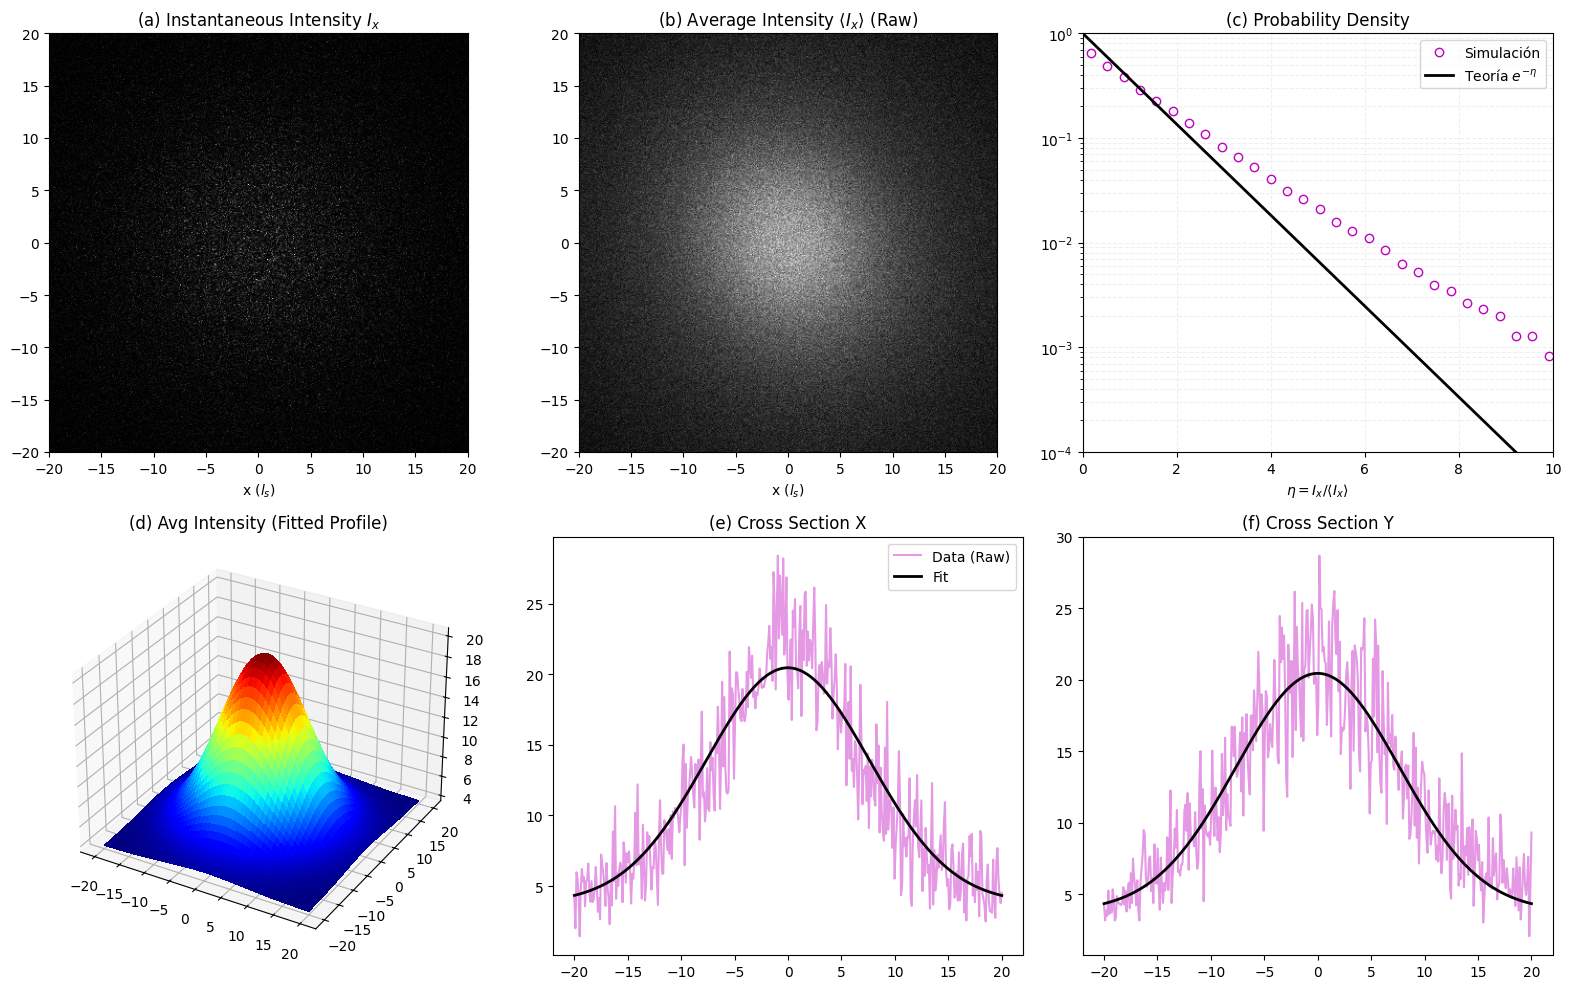

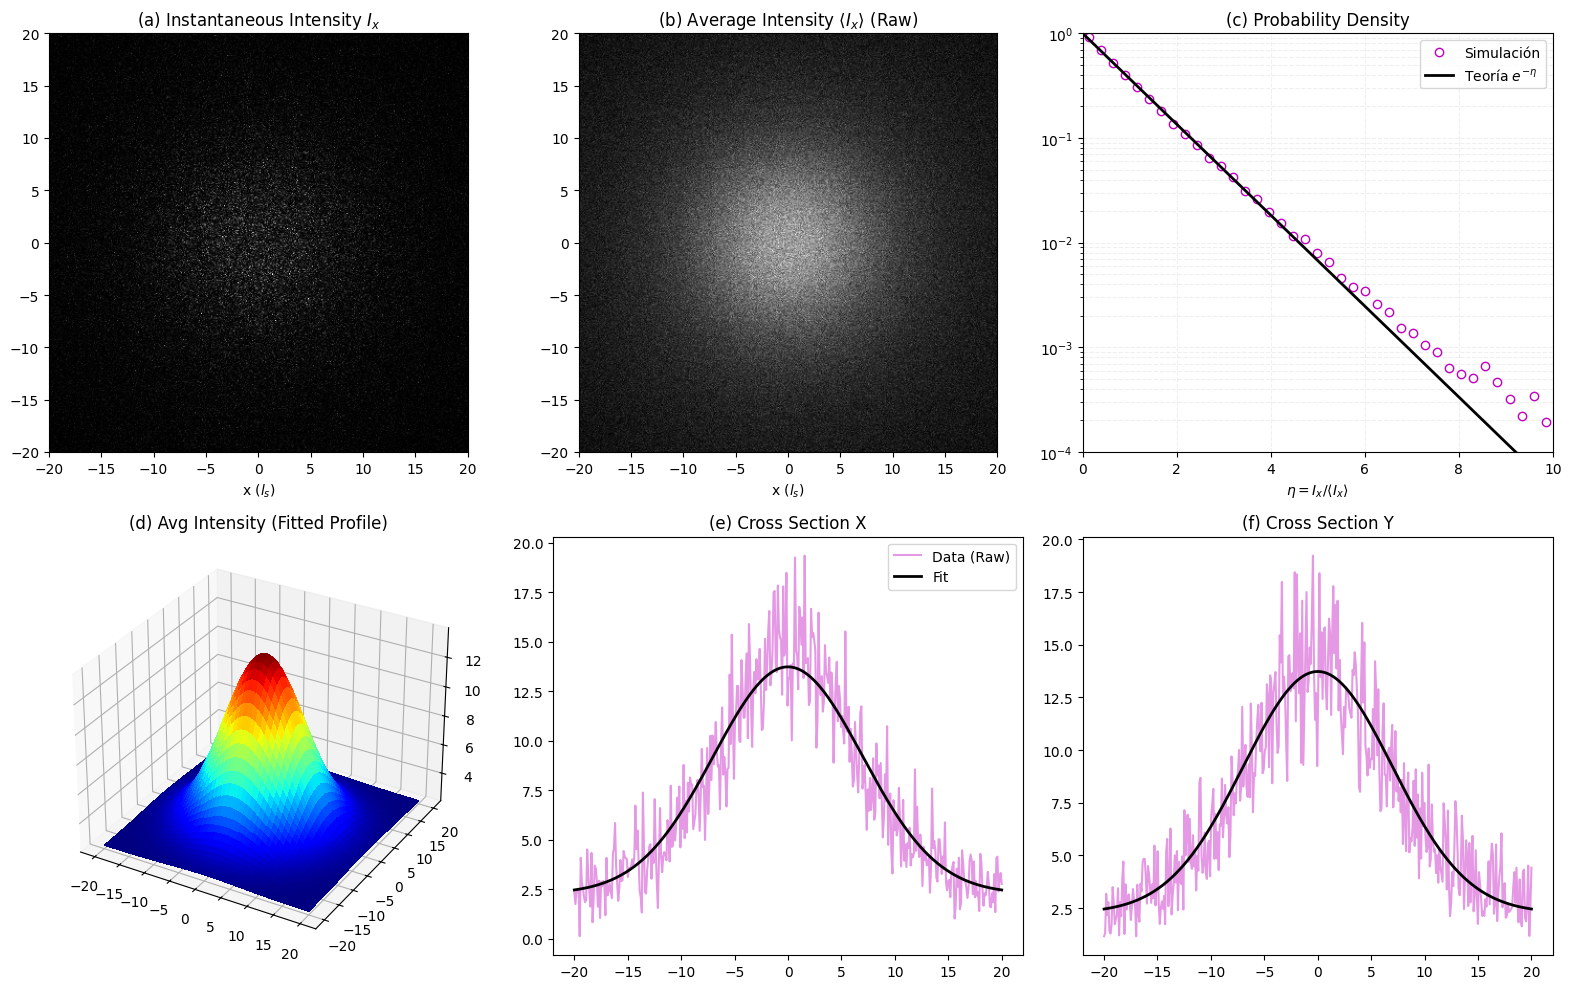

In [5]:
S0_t = data.sensor_data("planarfluence", "S0_t")
S1_t = data.sensor_data("planarfluence", "S1_t")
S2_t = data.sensor_data("planarfluence", "S2_t")
S3_t = data.sensor_data("planarfluence", "S3_t")

Ex = data.sensor_data("planarfield", "Ex")
Ey = data.sensor_data("planarfield", "Ey")

I_ave_x = (S0_t[0] + S1_t[0]) / 2
I_ave_y = (S0_t[0] - S1_t[0]) / 2
I_insta_x = np.abs(Ex)**2
I_insta_y = np.abs(Ey)**2

Eco = (Ex - 1j * Ey) / np.sqrt(2)
Ecross = (Ex + 1j * Ey) / np.sqrt(2)

I_ave_co = (S0_t[0] - S2_t[0]) / 2
I_ave_cross = (S0_t[0] - S3_t[0]) / 2
I_insta_co = np.abs(Eco)**2
I_insta_cross = np.abs(Ecross)**2

NN = meta_sensor_fluence['N_x']
HW = meta_sensor_fluence['len_x'] / 2
plot_figure_5_corrected(I_insta_x, I_ave_x, NN, HW)
plot_figure_5_corrected(I_insta_y, I_ave_y, NN, HW)

plot_figure_5_corrected(I_insta_co, I_ave_co, NN, HW)
plot_figure_5_corrected(I_insta_cross, I_ave_cross, NN, HW)
